In [58]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import shap
import pickle, json
from pathlib import Path

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


In [59]:
train_ml = pd.read_csv("train_ml.csv")
train_ml.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 139008 entries, 0 to 139007
Data columns (total 55 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   PM2.5          139008 non-null  float64
 1   PM10           139008 non-null  float64
 2   NO             139008 non-null  float64
 3   NO2            139008 non-null  float64
 4   NOx            139008 non-null  float64
 5   NH3            139008 non-null  float64
 6   SO2            139008 non-null  float64
 7   CO             139008 non-null  float64
 8   Ozone          139008 non-null  float64
 9   Benzene        139008 non-null  float64
 10  Toluene        139008 non-null  float64
 11  RH             139008 non-null  float64
 12  WS             139008 non-null  float64
 13  WD             139008 non-null  float64
 14  SR             139008 non-null  float64
 15  BP             139008 non-null  float64
 16  VWS            139008 non-null  float64
 17  TOT-RF         139008 non-nul

In [60]:
train_ml = pd.read_csv("train_ml.csv")
val_ml   = pd.read_csv("val_ml.csv")
test_ml  = pd.read_csv("test_ml.csv")

with open("city_map.json") as f:
    city_map = {int(k): v for k, v in json.load(f).items()}

TARGET = "PM2.5"

X_train = train_ml.drop(columns=[TARGET])
y_train = train_ml[TARGET]

X_val   = val_ml.drop(columns=[TARGET])
y_val   = val_ml[TARGET]

X_test  = test_ml.drop(columns=[TARGET])
y_test  = test_ml[TARGET]

print(f"Train : {X_train.shape}")
print(f"Val   : {X_val.shape}")
print(f"Test  : {X_test.shape}")
print(f"\nFeatures ({len(X_train.columns)}):", X_train.columns.tolist())
print(f"\nTarget range — Train: {y_train.min():.2f} to {y_train.max():.2f}")
print(f"Target range — Test : {y_test.min():.2f} to {y_test.max():.2f}")

Train : (139008, 54)
Val   : (52416, 54)
Test  : (17664, 54)

Features (54): ['PM10', 'NO', 'NO2', 'NOx', 'NH3', 'SO2', 'CO', 'Ozone', 'Benzene', 'Toluene', 'RH', 'WS', 'WD', 'SR', 'BP', 'VWS', 'TOT-RF', 'RF', 'AT', 'Month', 'Hour', 'VWS_direction', 'PM_ratio', 'NO2_NOx_ratio', 'Ventilation', 'Season_ord', 'DayOfWeek', 'Year', 'Hour_sin', 'Hour_cos', 'Month_sin', 'Month_cos', 'Day_sin', 'Day_cos', 'WD_sin', 'WD_cos', 'lag_1', 'lag_2', 'lag_3', 'lag_6', 'lag_12', 'lag_24', 'lag_48', 'lag_168', 'roll_mean_6', 'roll_std_6', 'roll_max_6', 'roll_mean_24', 'roll_std_24', 'roll_max_24', 'roll_mean_168', 'roll_std_168', 'roll_max_168', 'City_id']

Target range — Train: 0.01 to 993.09
Target range — Test : 0.39 to 836.15


In [61]:
# Reusable function for all models
results_log = []  # stores all results for final comparison table

def evaluate(model_name, split_name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f"\n{'='*45}")
    print(f"  {model_name}  |  {split_name}")
    print(f"{'='*45}")
    print(f"  RMSE : {rmse:.4f}")
    print(f"  MAE  : {mae:.4f}")
    print(f"  R²   : {r2:.4f}")
    results_log.append({
        "Model": model_name,
        "Split": split_name,
        "RMSE": round(rmse, 4),
        "MAE":  round(mae, 4),
        "R2":   round(r2, 4)
    })
    return rmse, mae, r2

In [62]:
lgb_model = lgb.LGBMRegressor(
    n_estimators      = 2000,
    learning_rate     = 0.05,
    num_leaves        = 64,
    max_depth         = -1,
    min_child_samples = 20,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    reg_alpha         = 0.1,
    reg_lambda        = 0.1,
    random_state      = 42,
    n_jobs            = -1,
    verbose           = -1
)

lgb_model.fit(
    X_train, y_train,
    eval_set  = [(X_train, y_train), (X_val, y_val)],
    eval_names= ["train", "val"],
    eval_metric = "rmse",
    callbacks = [
        lgb.early_stopping(stopping_rounds=50, verbose=True),
        lgb.log_evaluation(period=100)
    ]
)

print(f"\n✅ Training done — Best iteration: {lgb_model.best_iteration_}")

Training until validation scores don't improve for 50 rounds
[100]	train's rmse: 5.00305	train's l2: 25.0305	val's rmse: 5.95884	val's l2: 35.5078
[200]	train's rmse: 2.94358	train's l2: 8.66464	val's rmse: 5.81985	val's l2: 33.8707
[300]	train's rmse: 2.01984	train's l2: 4.07977	val's rmse: 5.74506	val's l2: 33.0057
[400]	train's rmse: 1.58476	train's l2: 2.51146	val's rmse: 5.71354	val's l2: 32.6445
Early stopping, best iteration is:
[399]	train's rmse: 1.59032	train's l2: 2.52911	val's rmse: 5.71151	val's l2: 32.6213

✅ Training done — Best iteration: 399


In [63]:
val_preds  = lgb_model.predict(X_val)
test_preds = lgb_model.predict(X_test)

# Clip predictions to valid PM2.5 range (can't be negative)
val_preds  = np.clip(val_preds,  0, None)
test_preds = np.clip(test_preds, 0, None)

evaluate("LightGBM", "Validation", y_val,  val_preds)
evaluate("LightGBM", "Test",       y_test, test_preds)


  LightGBM  |  Validation
  RMSE : 5.7111
  MAE  : 0.7609
  R²   : 0.9407

  LightGBM  |  Test
  RMSE : 8.0742
  MAE  : 1.3353
  R²   : 0.9515


(np.float64(8.07423001125982), 1.3352747031214036, 0.95150322211211)

In [64]:
print("\n=== LightGBM — Per City Test RMSE ===\n")

city_rmse = {}
temp = test_ml.copy()
temp["pred"] = test_preds

for city_id, city_name in sorted(city_map.items()):
    subset = temp[temp["City_id"] == city_id]
    if len(subset) == 0:
        print(f"  {city_name:22s} → No data in test set")
        continue
    rmse = np.sqrt(mean_squared_error(subset[TARGET], subset["pred"]))
    mae  = mean_absolute_error(subset[TARGET], subset["pred"])
    r2   = r2_score(subset[TARGET], subset["pred"])
    city_rmse[city_name] = rmse
    print(f"  {city_name:22s} → RMSE: {rmse:6.2f}  |  MAE: {mae:6.2f}  |  R²: {r2:.4f}  (n={len(subset):,})")


=== LightGBM — Per City Test RMSE ===

  Amaravati              → RMSE:   2.34  |  MAE:   1.15  |  R²: 0.9953  (n=2,208)
  Anantapur              → RMSE:   1.45  |  MAE:   0.60  |  R²: 0.9955  (n=2,208)
  Chittoor               → RMSE:  16.92  |  MAE:   3.07  |  R²: 0.8780  (n=2,208)
  Kadapa                 → RMSE:  12.54  |  MAE:   1.17  |  R²: 0.6518  (n=2,208)
  Rajamahendravaram      → RMSE:   1.51  |  MAE:   0.92  |  R²: 0.9985  (n=2,208)
  Tirupati               → RMSE:   7.25  |  MAE:   1.45  |  R²: 0.9609  (n=2,208)
  Vijayawada             → RMSE:   0.84  |  MAE:   0.51  |  R²: 0.9990  (n=2,208)
  Visakhapatnam          → RMSE:   3.85  |  MAE:   1.80  |  R²: 0.9920  (n=2,208)


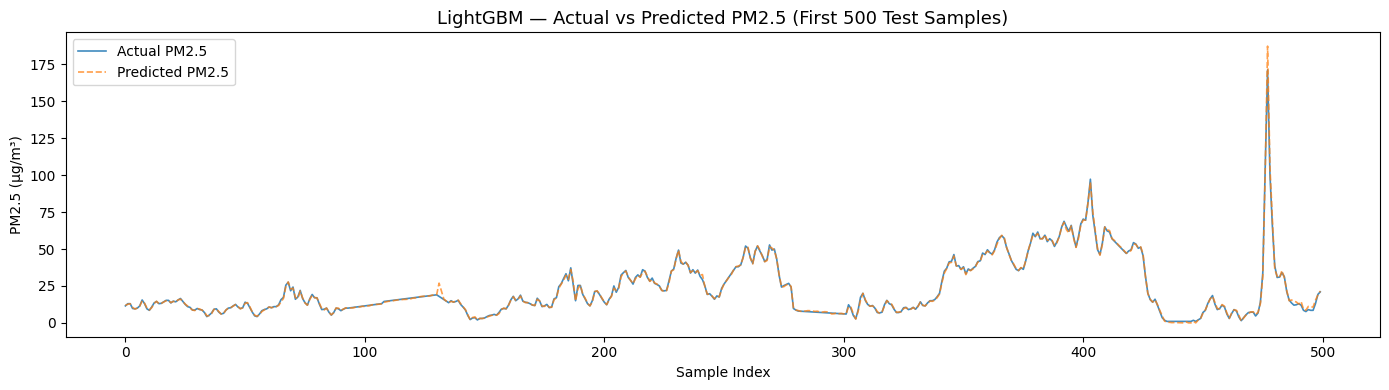

In [65]:
plt.figure(figsize=(14, 4))
plt.plot(y_test.values[:500], label="Actual PM2.5",    alpha=0.85, linewidth=1.2)
plt.plot(test_preds[:500],    label="Predicted PM2.5", alpha=0.75, linewidth=1.2, linestyle="--")
plt.title("LightGBM — Actual vs Predicted PM2.5 (First 500 Test Samples)", fontsize=13)
plt.xlabel("Sample Index")
plt.ylabel("PM2.5 (µg/m³)")
plt.legend()
plt.tight_layout()
plt.show()

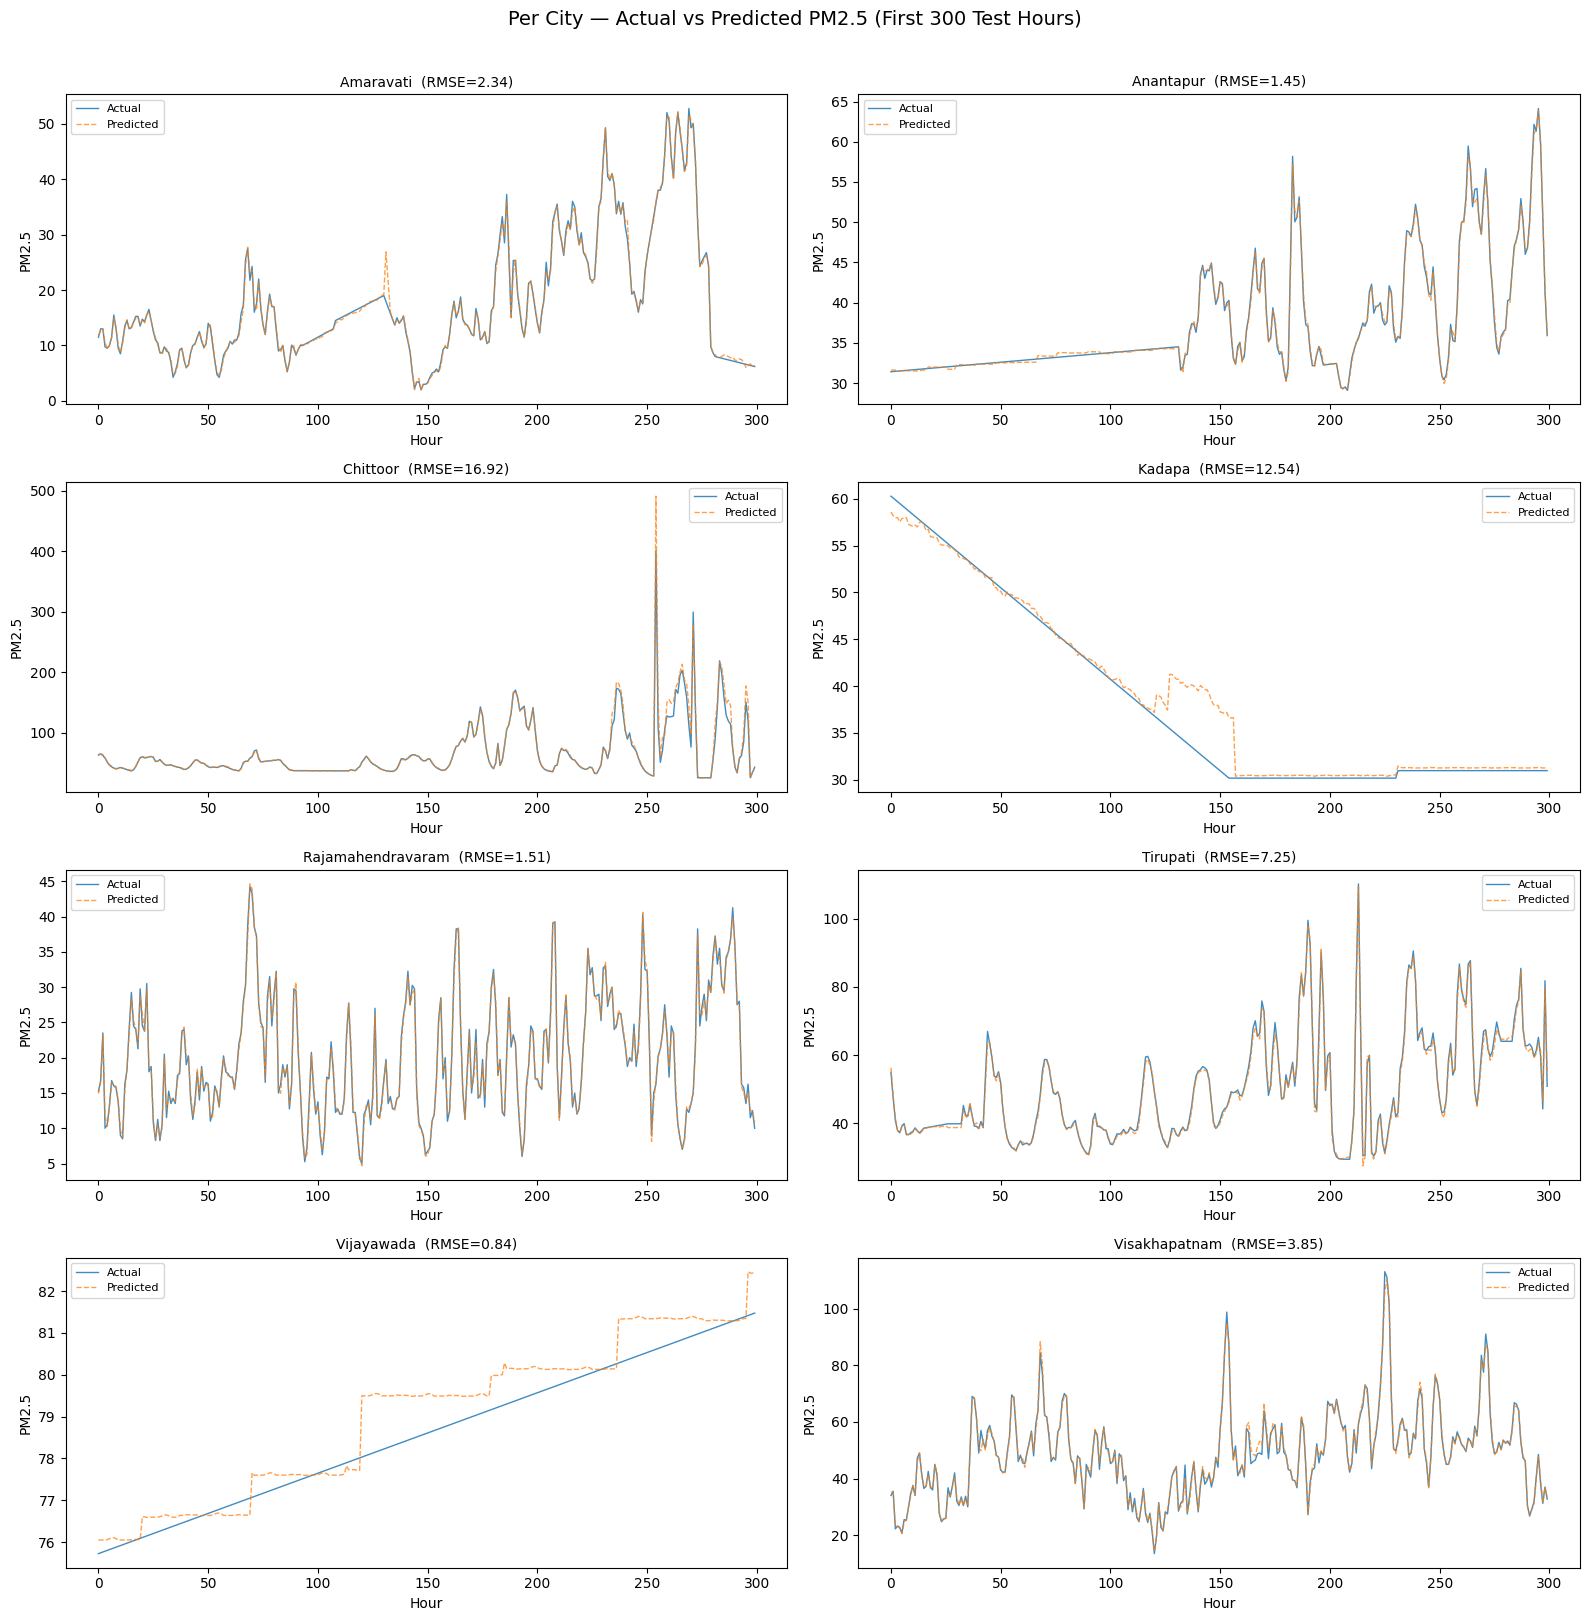

In [66]:
fig, axes = plt.subplots(4, 2, figsize=(16, 16))
axes = axes.flatten()

temp = test_ml.copy()
temp["pred"] = test_preds

for idx, (city_id, city_name) in enumerate(sorted(city_map.items())):
    subset = temp[temp["City_id"] == city_id].reset_index(drop=True)
    ax = axes[idx]
    ax.plot(subset[TARGET].values[:300], label="Actual",    alpha=0.85, linewidth=1.0)
    ax.plot(subset["pred"].values[:300], label="Predicted", alpha=0.75, linewidth=1.0, linestyle="--")
    rmse = city_rmse.get(city_name, 0)
    ax.set_title(f"{city_name}  (RMSE={rmse:.2f})", fontsize=10)
    ax.set_xlabel("Hour")
    ax.set_ylabel("PM2.5")
    ax.legend(fontsize=8)

plt.suptitle("Per City — Actual vs Predicted PM2.5 (First 300 Test Hours)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

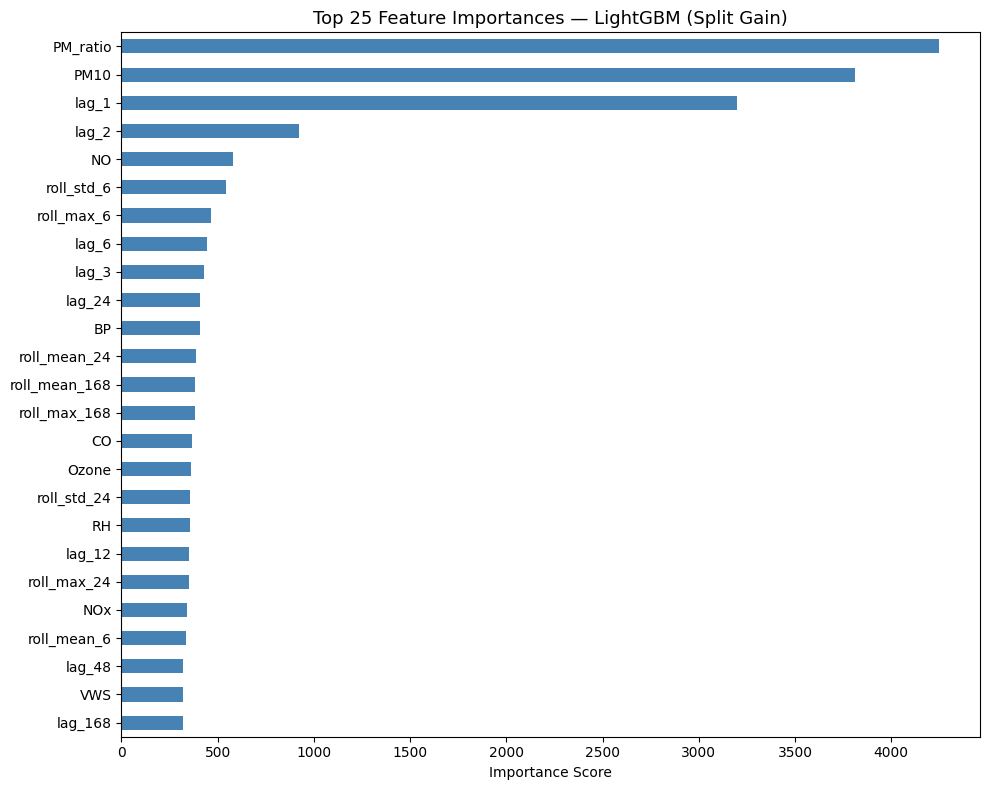


Top 10 features:
PM_ratio      4249
PM10          3810
lag_1         3199
lag_2          922
NO             581
roll_std_6     543
roll_max_6     463
lag_6          447
lag_3          431
lag_24         410


In [67]:
feat_imp = pd.Series(
    lgb_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
feat_imp.head(25).plot(kind="barh", color="steelblue")
plt.gca().invert_yaxis()
plt.title("Top 25 Feature Importances — LightGBM (Split Gain)", fontsize=13)
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

print("\nTop 10 features:")
print(feat_imp.head(10).to_string())

In [68]:
# SHAP on full 17k test set is manageable, but we sample for speed
# Use 2000 samples — representative enough
shap_sample = X_test.sample(2000, random_state=42).reset_index(drop=True)

print("Computing SHAP values on 2000 test samples...")
explainer   = shap.TreeExplainer(lgb_model)
shap_values = explainer.shap_values(shap_sample)

print(f"✅ SHAP values computed — shape: {shap_values.shape}")

Computing SHAP values on 2000 test samples...
✅ SHAP values computed — shape: (2000, 54)


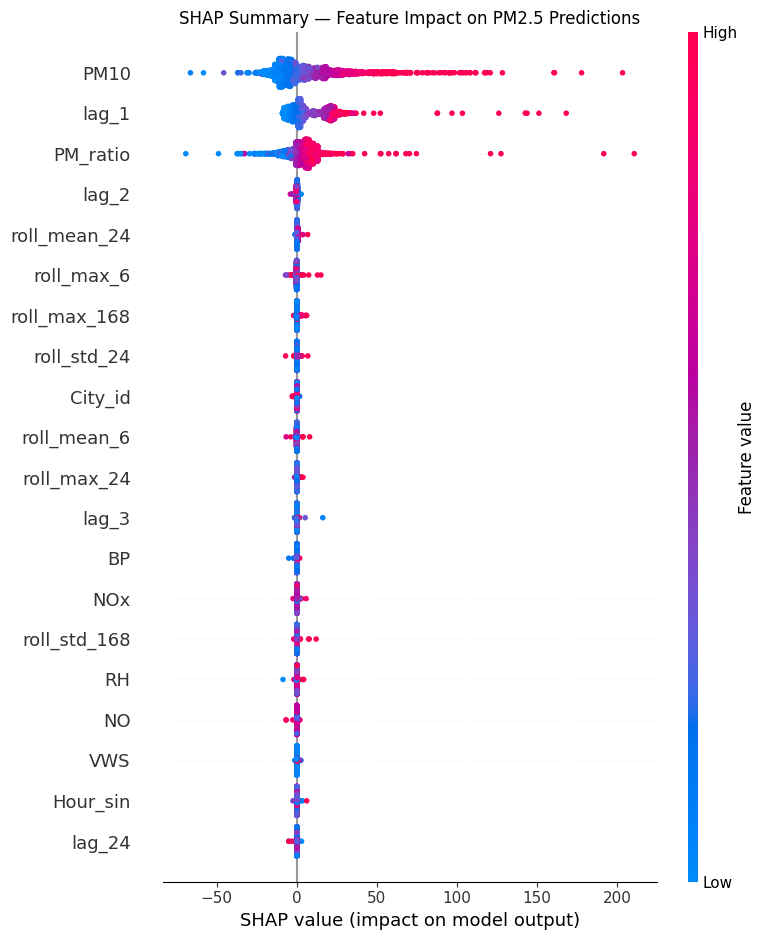

In [69]:
plt.figure()
shap.summary_plot(
    shap_values,
    shap_sample,
    max_display=20,
    show=False
)
plt.title("SHAP Summary — Feature Impact on PM2.5 Predictions", fontsize=12)
plt.tight_layout()
plt.show()

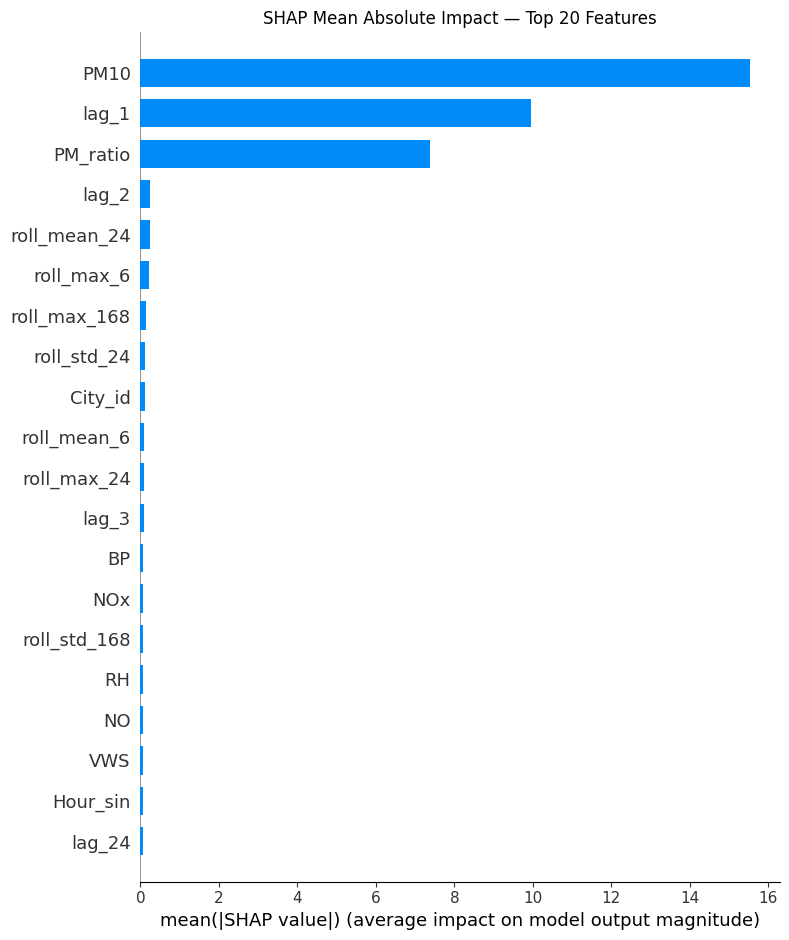

In [70]:
plt.figure()
shap.summary_plot(
    shap_values,
    shap_sample,
    plot_type="bar",
    max_display=20,
    show=False
)
plt.title("SHAP Mean Absolute Impact — Top 20 Features", fontsize=12)
plt.tight_layout()
plt.show()

In [71]:
print("=== SHAP Per City — Top 3 Feature Drivers ===\n")

temp_test = test_ml.copy()
temp_test_X = X_test.copy()

city_shap_results = {}

for city_id, city_name in sorted(city_map.items()):
    mask = temp_test["City_id"] == city_id
    city_X = temp_test_X[mask.values].reset_index(drop=True)

    n_samples = min(500, len(city_X))
    if n_samples < 10:
        print(f"  {city_name:22s} → Not enough samples")
        continue

    city_sample = city_X.sample(n_samples, random_state=42)
    sv = explainer.shap_values(city_sample)

    mean_abs = pd.Series(np.abs(sv).mean(axis=0), index=X_train.columns)
    top3 = mean_abs.sort_values(ascending=False).head(3)
    city_shap_results[city_name] = top3

    drivers = " | ".join([f"{feat} ({val:.3f})" for feat, val in top3.items()])
    print(f"  {city_name:22s} → {drivers}")

=== SHAP Per City — Top 3 Feature Drivers ===

  Amaravati              → PM10 (18.316) | lag_1 (10.230) | PM_ratio (7.371)
  Anantapur              → PM10 (8.757) | PM_ratio (6.534) | lag_1 (4.978)
  Chittoor               → PM10 (15.962) | PM_ratio (11.489) | lag_1 (10.577)
  Kadapa                 → PM10 (8.979) | PM_ratio (4.856) | lag_1 (4.552)
  Rajamahendravaram      → PM10 (18.158) | lag_1 (11.695) | PM_ratio (5.440)
  Tirupati               → PM10 (11.997) | lag_1 (7.855) | PM_ratio (7.136)
  Vijayawada             → lag_1 (13.847) | PM10 (13.778) | PM_ratio (9.698)
  Visakhapatnam          → PM10 (28.639) | lag_1 (14.949) | PM_ratio (6.950)


In [72]:
results_df = pd.DataFrame(results_log)
print("\n=== Full Results Summary ===\n")
print(results_df.to_string(index=False))

# Save
results_df.to_csv("model_results.csv", index=False)


=== Full Results Summary ===

   Model      Split   RMSE    MAE     R2
LightGBM Validation 5.7111 0.7609 0.9407
LightGBM       Test 8.0742 1.3353 0.9515
